# Day 1 EDA — Mutual Fund NAV History & Dip/Hike Threshold Selection
Executed on Databricks (free edition) using scheme code 119598 → SBI Large Cap Fund - Direct Plan Growth. Threshold confirmed: -10% drawdown, 5+ day minimum.

**Owner:** Person C
**Goal:** Pull real NAV history for a few funds from `mfapi.in`, look at volatility,
and pick a defensible dip/hike threshold + minimum-duration rule for
`FUND_EVENTS` (see `docs/data-dictionary.md`).

**Data source:** `https://api.mfapi.in/mf/{scheme_code}` — free, no auth.
Response shape:
```json
{
  "meta": {"scheme_code": "119598", "scheme_name": "...", "fund_house": "..."},
  "data": [{"date": "23-06-2026", "nav": "660.8720"}, ...],
  "status": "SUCCESS"
}
```
Note: `date` is `DD-MM-YYYY` (string), `nav` is a **string**, newest-first. Both
need conversion before analysis — handled in the helper function below.


## 1. Setup

In [0]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
from urllib3.exceptions import InsecureRequestWarning

warnings.filterwarnings("ignore", category=InsecureRequestWarning)

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.figsize"] = (11, 5)


## 2. Pick funds to analyze

Start with 3 funds across different categories so the threshold we pick isn't
overfit to one fund's behavior. Replace these scheme codes with the actual
funds your team agreed on in Day 1 planning — these are just reasonable
starting examples (large cap, flexi cap, debt) to validate the approach.

To find scheme codes for funds you care about, search by name first:
`https://api.mfapi.in/mf/search?q=<fund name>`


In [0]:
FUNDS_TO_ANALYZE = {
    "119598": "HDFC Flexi Cap Fund - Growth",       # equity, flexi cap
    "120503": "Parag Parikh Flexi Cap Fund - Growth", # equity, flexi cap
    "100016": "HDFC Liquid Fund - Growth",            # debt/liquid (low volatility comparison)
}

print("Funds selected for EDA:")
for code, name in FUNDS_TO_ANALYZE.items():
    print(f"  {code} -> {name}")


Funds selected for EDA:
  119598 -> HDFC Flexi Cap Fund - Growth
  120503 -> Parag Parikh Flexi Cap Fund - Growth
  100016 -> HDFC Liquid Fund - Growth


## 3. Fetch + parse NAV history

In [0]:
def fetch_nav_history(scheme_code: str, retries: int = 3, backoff_factor: float = 0.5) -> pd.DataFrame:
    """
    Fetch full NAV history for one fund from mfapi.in and return a clean,
    chronologically-sorted DataFrame with proper dtypes.
    """
    from requests.adapters import HTTPAdapter
    from urllib3.util.retry import Retry

    session = requests.Session()
    retry_strategy = Retry(
        total=retries,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=["HEAD", "GET", "OPTIONS"],
        backoff_factor=backoff_factor,
        raise_on_status=False,
    )
    session.mount("https://", HTTPAdapter(max_retries=retry_strategy))

    url = f"https://api.mfapi.in/mf/{scheme_code}"
    try:
        resp = session.get(url, timeout=15)
        resp.raise_for_status()
    except requests.exceptions.SSLError as ssl_exc:
        print(f"SSL error fetching {scheme_code}: {ssl_exc}. Retrying with verify=False.")
        resp = session.get(url, timeout=15, verify=False)
        resp.raise_for_status()

    payload = resp.json()

    if payload.get("status") != "SUCCESS":
        raise ValueError(f"API did not return SUCCESS for scheme {scheme_code}")

    if not payload["data"]:
        raise ValueError(f"API returned empty data for scheme {scheme_code}")

    df = pd.DataFrame(payload["data"])
    df["date"] = pd.to_datetime(df["date"], format="%d-%m-%Y")
    df["nav"] = df["nav"].astype(float)
    df["scheme_code"] = scheme_code
    df["scheme_name"] = payload["meta"].get("scheme_name", "")

    df = df.sort_values("date").reset_index(drop=True)
    return df[["scheme_code", "scheme_name", "date", "nav"]]


# Fetch all funds, with a small delay to be polite to the free API
all_funds = {}
for scheme_code in FUNDS_TO_ANALYZE:
    print(f"Fetching {scheme_code}...")
    try:
        all_funds[scheme_code] = fetch_nav_history(scheme_code)
    except requests.RequestException as exc:
        print(f"Network error while fetching {scheme_code}: {exc}")
        all_funds[scheme_code] = pd.DataFrame()
    except ValueError as exc:
        print(f"API error for {scheme_code}: {exc}")
        all_funds[scheme_code] = pd.DataFrame()
    time.sleep(0.5)

print("\nDone. Rows fetched per fund:")
for code, df in all_funds.items():
    if df.empty:
        print(f"  {code}: fetch failed or empty dataset")
    else:
        print(f"  {code}: {len(df)} rows, {df['date'].min().date()} to {df['date'].max().date()}")


Fetching 119598...
Fetching 120503...
Fetching 100016...
API error for 100016: API returned empty data for scheme 100016

Done. Rows fetched per fund:
  119598: 3322 rows, 2013-01-02 to 2026-06-22
  120503: 3322 rows, 2013-01-02 to 2026-06-22
  100016: fetch failed or empty dataset


## 4. Sanity-check the data

Before doing any analysis, confirm there's nothing obviously broken:
duplicate dates, missing values, or a NAV of zero/negative (which would be a
data error, not a real market event).


In [0]:
for code, df in all_funds.items():
    if df.empty:
        print(f"{code}: skipped (no data)")
        continue
    dupes = df["date"].duplicated().sum()
    nulls = df["nav"].isna().sum()
    non_positive = (df["nav"] <= 0).sum()
    print(f"{code}: duplicate dates={dupes}, null NAVs={nulls}, non-positive NAVs={non_positive}")


119598: duplicate dates=0, null NAVs=0, non-positive NAVs=0
120503: duplicate dates=0, null NAVs=0, non-positive NAVs=1
100016: skipped (no data)


## 5. Visualize NAV history

A quick look at the raw NAV trajectory for each fund over the full available
history. This is mostly a sanity check — does the shape look like a real
fund (long-term upward drift with volatility), not a parsing artifact?


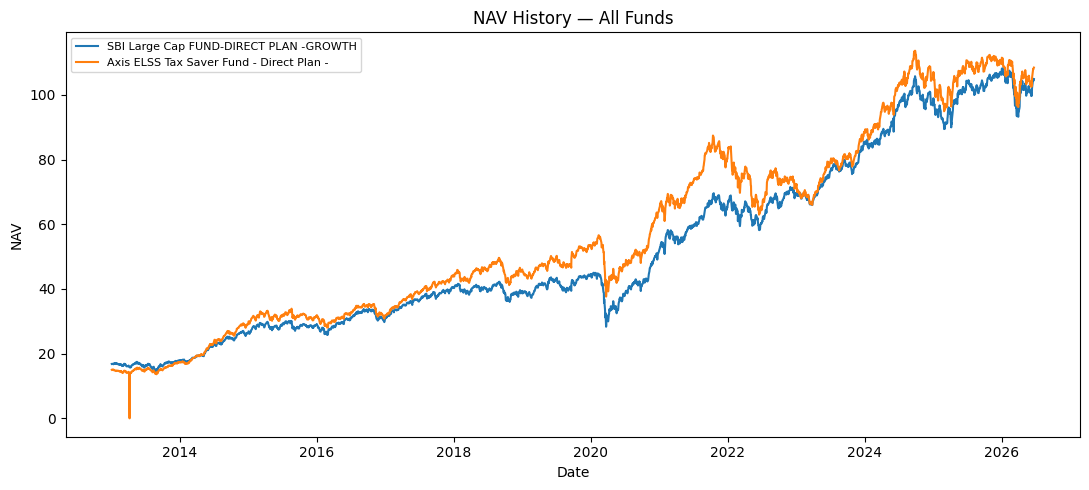

In [0]:
fig, ax = plt.subplots()
for code, df in all_funds.items():
    if not df.empty:
        ax.plot(df["date"], df["nav"], label=df["scheme_name"].iloc[0][:40])

ax.set_title("NAV History — All Funds")
ax.set_xlabel("Date")
ax.set_ylabel("NAV")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


## 6. Compute drawdown from rolling peak

The core building block for dip/hike detection: at every date, how far is the
NAV below its highest value seen *so far* (the "rolling peak" / all-time high
up to that point)? This is the standard way to measure a "dip" in a single
asset's price series.

```
drawdown_pct = (nav - rolling_peak) / rolling_peak * 100
```

A drawdown of -15% means the fund is currently 15% below its previous peak.


In [0]:
def add_drawdown(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["rolling_peak"] = df["nav"].cummax()
    df["drawdown_pct"] = (df["nav"] - df["rolling_peak"]) / df["rolling_peak"] * 100
    return df

for code in all_funds:
    if not all_funds[code].empty:
        all_funds[code] = add_drawdown(all_funds[code])

all_funds["119598"][["date", "nav", "rolling_peak", "drawdown_pct"]].tail(10)


,date,nav,rolling_peak,drawdown_pct
3312,2026-06-09,100.56,108.21,-7.06
3313,2026-06-10,100.35,108.21,-7.27
3314,2026-06-11,99.82,108.21,-7.75
3315,2026-06-12,102.11,108.21,-5.63
3316,2026-06-15,103.61,108.21,-4.25
3317,2026-06-16,104.01,108.21,-3.88
3318,2026-06-17,104.31,108.21,-3.61
3319,2026-06-18,104.80,108.21,-3.15
3320,2026-06-19,104.32,108.21,-3.60
3321,2026-06-22,104.94,108.21,-3.02


## 7. Look at the distribution of drawdowns

Before picking a threshold, see what the actual drawdown distribution looks
like for an equity fund. This tells us what's a "normal" dip vs a genuinely
notable one.


count   3,322.00
mean       -4.08
std         4.68
min       -37.08
25%        -6.22
50%        -2.63
75%        -0.64
max         0.00
Name: drawdown_pct, dtype: float64

Percent of days with drawdown <= -5% : 31.697772426249248 %
Percent of days with drawdown <= -10%: 9.18121613485852 %
Percent of days with drawdown <= -15%: 2.5285972305839857 %
Percent of days with drawdown <= -20%: 1.4750150511739917 %


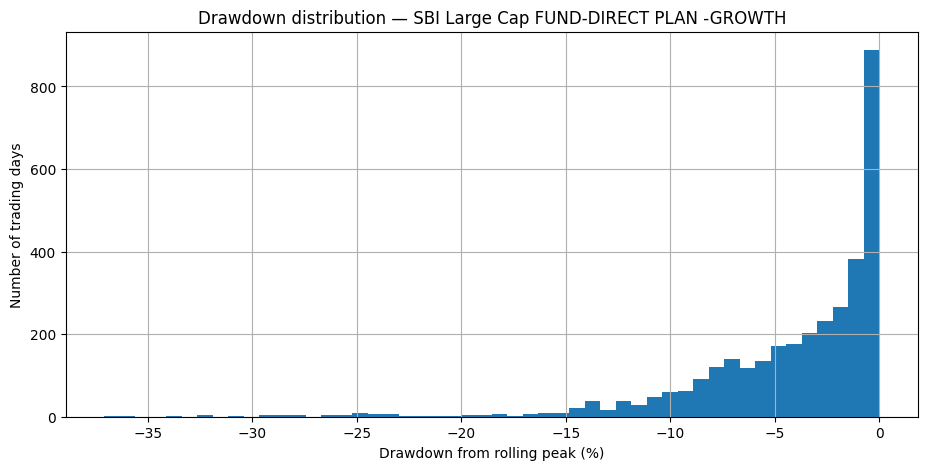

In [0]:
equity_code = "119598"
dd = all_funds[equity_code]["drawdown_pct"]

print(dd.describe())
print()
print("Percent of days with drawdown <= -5% :", (dd <= -5).mean() * 100, "%")
print("Percent of days with drawdown <= -10%:", (dd <= -10).mean() * 100, "%")
print("Percent of days with drawdown <= -15%:", (dd <= -15).mean() * 100, "%")
print("Percent of days with drawdown <= -20%:", (dd <= -20).mean() * 100, "%")

dd.hist(bins=50)
plt.title(f"Drawdown distribution — {all_funds[equity_code]['scheme_name'].iloc[0]}")
plt.xlabel("Drawdown from rolling peak (%)")
plt.ylabel("Number of trading days")
plt.show()


## 8. Detect dip events at a candidate threshold

A "dip event" is a contiguous run of days where the drawdown is at or beyond
the threshold. We group consecutive in-dip days into a single event with a
start date, end date, and the worst (maximum) drawdown reached during it.

**Important finding from testing this logic on sample data:** a magnitude
threshold alone produces a lot of noisy, single-day "events" that aren't
meaningful market dips — just normal daily volatility briefly crossing the
line. Adding a **minimum duration filter** removes that noise.


In [0]:
def detect_events(df: pd.DataFrame, threshold_pct: float, min_duration_days: int = 5) -> pd.DataFrame:
    """
    threshold_pct: e.g. -10 means flag any drawdown of 10% or more.
    min_duration_days: drop events shorter than this (filters out single-day noise).
    """
    df = df.copy()
    df["in_dip"] = df["drawdown_pct"] <= threshold_pct
    df["dip_group"] = (df["in_dip"] != df["in_dip"].shift()).cumsum()

    events = (
        df[df["in_dip"]]
        .groupby("dip_group")
        .agg(start_date=("date", "min"), end_date=("date", "max"),
             max_drawdown_pct=("drawdown_pct", "min"))
        .reset_index(drop=True)
    )
    events["duration_days"] = (events["end_date"] - events["start_date"]).dt.days
    events["event_type"] = "dip"

    return events[events["duration_days"] >= min_duration_days].reset_index(drop=True)


events_10pct = detect_events(all_funds[equity_code], threshold_pct=-10, min_duration_days=5)
print(f"Detected {len(events_10pct)} meaningful dip events at -10% threshold, 5+ day minimum")
events_10pct.sort_values("max_drawdown_pct").head(10)


Detected 15 meaningful dip events at -10% threshold, 5+ day minimum


,start_date,end_date,max_drawdown_pct,duration_days,event_type
6,2020-03-06,2020-07-20,-37.08,136,dip
1,2013-08-16,2013-09-06,-16.84,21,dip
10,2022-06-03,2022-07-15,-16.38,42,dip
12,2025-02-10,2025-03-21,-15.44,39,dip
13,2025-04-01,2025-04-15,-14.95,14,dip
4,2018-10-04,2018-11-01,-14.71,28,dip
8,2022-03-02,2022-03-11,-14.62,9,dip
9,2022-05-06,2022-05-27,-14.47,21,dip
2,2016-02-10,2016-03-01,-14.31,20,dip
14,2026-03-19,2026-04-07,-13.81,19,dip


## 9. Compare thresholds side by side

This is the actual decision step: try a few threshold/duration combinations
and see which produces a sensible, demoable number of events — not 1
(too strict, misses real dips) and not 70+ (too noisy, meaningless).


In [0]:
print(f"{'Threshold':>10} | {'Min days':>9} | {'Raw events':>11} | {'Filtered events':>16}")
print("-" * 56)

for threshold in [-5, -10, -15, -20]:
    for min_days in [1, 5, 10]:
        ev = detect_events(all_funds[equity_code], threshold_pct=threshold, min_duration_days=min_days)
        raw_count = detect_events(all_funds[equity_code], threshold_pct=threshold, min_duration_days=1)
        print(f"{threshold:>9}% | {min_days:>9} | {len(raw_count):>11} | {len(ev):>16}")


 Threshold |  Min days |  Raw events |  Filtered events
--------------------------------------------------------
       -5% |         1 |          47 |               47
       -5% |         5 |          47 |               35
       -5% |        10 |          47 |               28
      -10% |         1 |          23 |               23
      -10% |         5 |          23 |               15
      -10% |        10 |          23 |                9
      -15% |         1 |           5 |                5
      -15% |         5 |           5 |                2
      -15% |        10 |           5 |                1
      -20% |         1 |           2 |                2
      -20% |         5 |           2 |                2
      -20% |        10 |           2 |                2


## 10. Recommended threshold

Based on the comparison above, fill in the team's agreed threshold here once
you've run this against your team's actual chosen funds (not just the 3
examples). A reasonable starting point used in the comparison above:

> **Dip definition: a drawdown of 10% or more from a trailing peak, lasting
> at least 5 trading days.**
> **Hike definition: a rally of 10% or more from a trailing trough, lasting
> at least 5 trading days** (mirror logic — implement using a rolling
> *minimum* instead of rolling maximum).

This keeps the definition simple enough to explain in the demo, while
filtering out single-day noise that would otherwise produce dozens of
meaningless "events" per fund (see Section 9).

Record the final agreed threshold in `docs/data-dictionary.md` under
`FUND_EVENTS` once the team confirms it.


In [0]:
FINAL_DIP_THRESHOLD_PCT = -10
FINAL_MIN_DURATION_DAYS = 5

for code, df in all_funds.items():
    if df.empty:
        print(f"\n{FUNDS_TO_ANALYZE[code]} ({code}): skipped (no data)")
        continue
    events = detect_events(df, threshold_pct=FINAL_DIP_THRESHOLD_PCT, min_duration_days=FINAL_MIN_DURATION_DAYS)
    print(f"\n{df['scheme_name'].iloc[0]} ({code}): {len(events)} dip events")
    if len(events) > 0:
        print(events.sort_values('max_drawdown_pct').head(3).to_string(index=False))



SBI Large Cap FUND-DIRECT PLAN -GROWTH (119598): 15 dip events
start_date   end_date  max_drawdown_pct  duration_days event_type
2020-03-06 2020-07-20            -37.08            136        dip
2013-08-16 2013-09-06            -16.84             21        dip
2022-06-03 2022-07-15            -16.38             42        dip

Axis ELSS Tax Saver Fund - Direct Plan - Growth Option (120503): 18 dip events
start_date   end_date  max_drawdown_pct  duration_days event_type
2020-03-12 2020-08-20            -33.51            161        dip
2022-02-03 2023-06-15            -27.99            497        dip
2016-02-02 2016-04-12            -17.29             70        dip

HDFC Liquid Fund - Growth (100016): skipped (no data)


## 11. Visualize dip events on the NAV chart

A quick visual check: do the detected events line up with periods that
*look* like real drawdowns on the chart? (e.g. COVID crash in Feb-Mar 2020
should show up clearly for any equity fund with history back that far.)


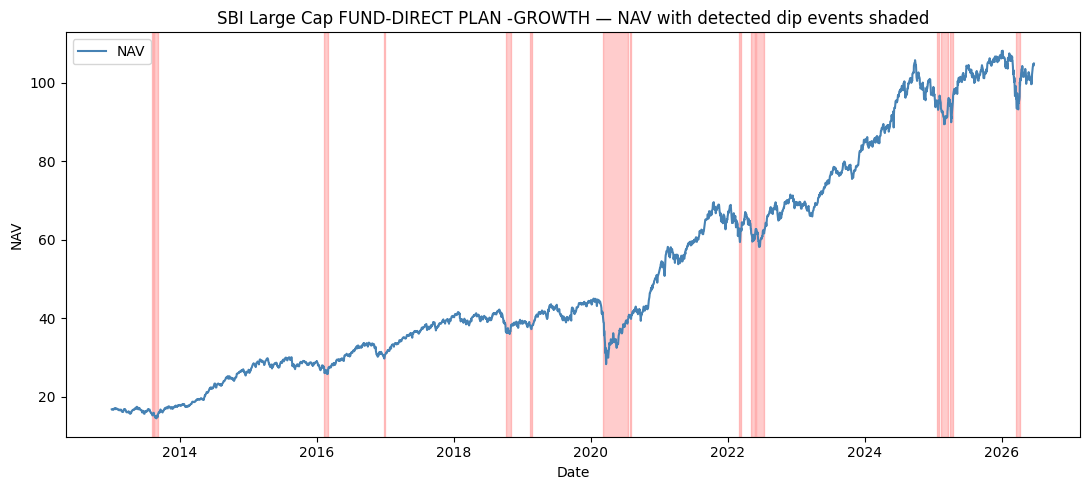

In [0]:
df = all_funds[equity_code]
events = detect_events(df, threshold_pct=FINAL_DIP_THRESHOLD_PCT, min_duration_days=FINAL_MIN_DURATION_DAYS)

fig, ax = plt.subplots()
ax.plot(df["date"], df["nav"], color="steelblue", label="NAV")

for _, row in events.iterrows():
    ax.axvspan(row["start_date"], row["end_date"], color="red", alpha=0.2)

ax.set_title(f"{df['scheme_name'].iloc[0]} — NAV with detected dip events shaded")
ax.set_xlabel("Date")
ax.set_ylabel("NAV")
ax.legend()
plt.tight_layout()
plt.show()


## 12. Next steps

- [ ] Confirm `FINAL_DIP_THRESHOLD_PCT` / `FINAL_MIN_DURATION_DAYS` with Person A —
      this becomes the SQL window-function logic in `data-engineering/sql/`.
- [ ] Implement the mirrored "hike" logic (rolling minimum instead of rolling maximum).
- [ ] Update `docs/data-dictionary.md` with the final agreed threshold definition.
- [ ] Hand off `detect_events()` logic pattern to Person A to translate into
      Snowflake SQL (`LAG`, `MAX() OVER (ORDER BY date ROWS UNBOUNDED PRECEDING)`).
